### Import libraries for data processing and weather collection


In [1]:
# Import pandas to read, store, and modify tables as DataFrames
import pandas as pd

# Import duckdb to run SQL queries on tabular data
import duckdb

# Import the Open-Meteo client for downloading weather data
import openmeteo_requests

# Import requests_cache to save API responses locally
import requests_cache

# Import retry to repeat failed API requests automatically
from retry_requests import retry

### Load and combine the price dataset

In [2]:
# Load and combine day-ahead electricity price data from three CSV files
# ignore_index=True creates a new continuous row index after concatenation
prices = pd.concat([
    pd.read_csv("../data/Day-ahead_prices_201901010000_202201010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Day-ahead_prices_202201010000_202501010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Day-ahead_prices_202501010000_202603060000_Hour.csv", sep=";")
], ignore_index=True)

### Load and combine the consumption dataset

In [3]:
# Load and combine forecasted electricity consumption data from three CSV files
# ignore_index=True creates a new continuous row index after concatenation
consumption = pd.concat([
    pd.read_csv("../data/Forecasted_consumption_201901010000_202201010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Forecasted_consumption_202201010000_202501010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Forecasted_consumption_202501010000_202603060000_Hour.csv", sep=";")
], ignore_index=True)

### Load and combine the generation dataset

In [4]:
# Load and combine forecasted electricity generation data from three CSV files
# ignore_index=True creates a new continuous row index after concatenation
generation = pd.concat([
    pd.read_csv("../data/Forecasted_generation_Day-Ahead_201901010000_202201010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Forecasted_generation_Day-Ahead_202201010000_202501010000_Hour.csv", sep=";"),
    pd.read_csv("../data/Forecasted_generation_Day-Ahead_202501010000_202603060000_Hour.csv", sep=";")
], ignore_index=True)

### Check the size of the loaded datasets

In [5]:
# Display the size of each combined DataFrame as (rows, columns)
print(f"Prices:      {prices.shape}")
print(f"Consumption: {consumption.shape}")
print(f"Generation:  {generation.shape}")

Prices:      (62904, 19)
Consumption: (62904, 4)
Generation:  (62904, 8)


### Preview the imported datasets

In [6]:
# Display the first 2 rows of the prices DataFrame
display(prices.head(2))

# Display the first 2 rows of the consumption DataFrame
display(consumption.head(2))

# Display the first 2 rows of the generation DataFrame
display(generation.head(2))

,Start date,End date,Germany/Luxembourg [€/MWh] Calculated resolutions,∅ DE/LU neighbours [€/MWh] Calculated resolutions,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,Switzerland [€/MWh] Calculated resolutions,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions
0,"Jan 1, 2019 12:00 AM","Jan 1, 2019 1:00 AM",28.32,-,69.49,28.32,28.32,51.0,68.92,48.77,33.48,-,28.32,50.26,8.50,-,51.00,51.0,59.9
1,"Jan 1, 2019 1:00 AM","Jan 1, 2019 2:00 AM",10.07,-,66.58,10.07,10.07,46.27,64.98,49.25,39.76,-,10.07,48.74,3.97,-,46.27,46.27,52.71


,Start date,End date,grid load [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"Jan 1, 2019 12:00 AM","Jan 1, 2019 1:00 AM","43,213.25","19,264.50"
1,"Jan 1, 2019 1:00 AM","Jan 1, 2019 2:00 AM","41,275.75","15,607.00"


,Start date,End date,Total [MWh] Calculated resolutions,Photovoltaics and wind [MWh] Calculated resolutions,Wind offshore [MWh] Calculated resolutions,Wind onshore [MWh] Calculated resolutions,Photovoltaics [MWh] Calculated resolutions,Other [MWh] Calculated resolutions
0,"Jan 1, 2019 12:00 AM","Jan 1, 2019 1:00 AM","51,011.46","23,948.75","5,069.00","18,879.75",0.00,"27,062.71"
1,"Jan 1, 2019 1:00 AM","Jan 1, 2019 2:00 AM","51,016.93","25,668.75","5,042.25","20,626.50",0.00,"25,348.18"


### Standardize the timestamp column name

In [7]:
# Rename the common time column to "timestamp" in the consumption DataFrame
consumption = consumption.rename(columns={"Start date": "timestamp"})

# Rename the common time column to "timestamp" in the prices DataFrame
prices = prices.rename(columns={"Start date": "timestamp"})

# Rename the common time column to "timestamp" in the generation DataFrame
generation = generation.rename(columns={"Start date": "timestamp"})

### Merge the energy datasets with SQL

In [8]:
# Use a SQL query in duckdb to join the three DataFrames on the timestamp column
df = duckdb.query("""
    SELECT 
        p.timestamp,
        p."Germany/Luxembourg [€/MWh] Calculated resolutions" AS price,
        c."grid load [MWh] Calculated resolutions" AS load,
        g."Wind offshore [MWh] Calculated resolutions" AS wind_offshore,
        g."Wind onshore [MWh] Calculated resolutions" AS wind_onshore,
        g."Photovoltaics [MWh] Calculated resolutions" AS solar
    FROM prices p
    JOIN consumption c ON p.timestamp = c.timestamp
    JOIN generation g ON p.timestamp = g.timestamp
""").fetchdf()

### Inspect the merged energy dataset

In [9]:
# Display the first rows of the merged DataFrame
print(df.head())

# Display the number of rows and columns as (rows, columns)
print(df.shape)

# Count missing values in each column
print(df.isnull().sum())

              timestamp  price       load wind_offshore wind_onshore solar
0  Jan 1, 2019 12:00 AM  28.32  43,213.25      5,069.00    18,879.75  0.00
1   Jan 1, 2019 1:00 AM  10.07  41,275.75      5,042.25    20,626.50  0.00
2   Jan 1, 2019 2:00 AM  -4.08  40,187.50      5,028.50    22,355.50  0.00
3   Jan 1, 2019 3:00 AM  -9.91  39,909.00      4,977.75    24,032.50  0.00
4   Jan 1, 2019 4:00 AM  -7.41  40,258.00      4,907.25    25,452.00  0.00
(62946, 6)
timestamp        0
price            0
load             0
wind_offshore    0
wind_onshore     0
solar            0
dtype: int64


### Import libraries for weather data collection

In [10]:
# Import the Open-Meteo client for downloading weather data
import openmeteo_requests

# Import requests_cache to save API responses locally
import requests_cache

# Import retry to repeat failed API requests automatically
from retry_requests import retry

### Create a cached session for weather API requests

In [11]:
# Create a cached session so downloaded API responses can be reused
cache_session = requests_cache.CachedSession(".cache", expire_after=-1)

# Add automatic retries to the cached session for failed requests
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)

# Create the Open-Meteo client with the configured session
openmeteo = openmeteo_requests.Client(session=retry_session)

### Define the cities for weather data collection

In [12]:
# Define the selected cities with their latitude and longitude coordinates
cities = {
    "Berlin":  (52.52, 13.41),
    "Munich":  (48.14, 11.58),
    "Hamburg": (53.55, 10.00),
    "Cologne": (50.94,  6.96)
}

### Create a list to store the weather data for each city

In [13]:
# Create an empty list to store one weather DataFrame per city
weather_dfs = []

### Download hourly weather data for each city

In [14]:
# Loop through each city and its latitude and longitude values
for city, (lat, lon) in cities.items():
    
    # Define the API request parameters for the current city
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2019-01-01",
        "end_date": "2026-03-05",
        "hourly": [
            "temperature_2m",
            "wind_speed_100m"
        ],
        "timezone": "Europe/Berlin"
    }
    
    # Request historical weather data from the Open-Meteo archive API
    responses = openmeteo.weather_api(
        "https://archive-api.open-meteo.com/v1/archive",
        params=params
    )
    
    # Select the first response object
    response = responses[0]
    
    # Extract the hourly data block from the response
    hourly = response.Hourly()
    
    # Create a DataFrame with timestamps, temperature, and wind speed for the current city
    weather_df = pd.DataFrame({
        "timestamp": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        ),
        f"temp_{city}": hourly.Variables(0).ValuesAsNumpy(),
        f"wind_speed_{city}": hourly.Variables(1).ValuesAsNumpy(),
    })
    
    # Store the current city's weather DataFrame in the list
    weather_dfs.append(weather_df)
    
    # Print a short message after the download is completed
    print(f"✅ {city} downloaded!")

✅ Berlin downloaded!
✅ Munich downloaded!
✅ Hamburg downloaded!
✅ Cologne downloaded!


### Merge the weather data from all selected cities

In [15]:
# Start with the weather DataFrame of the first city
weather_final = weather_dfs[0]

# Merge the remaining city weather DataFrames on the timestamp column
for w in weather_dfs[1:]:
    weather_final = weather_final.merge(w, on="timestamp")

### Calculate the average temperature and wind speed across all selected cities

In [16]:
# Calculate the row-wise mean temperature across the four city columns
weather_final["temperature"] = weather_final[
    ["temp_Berlin", "temp_Munich", "temp_Hamburg", "temp_Cologne"]
].mean(axis=1)

# Calculate the row-wise mean wind speed across the four city columns
weather_final["wind_speed"] = weather_final[
    ["wind_speed_Berlin", "wind_speed_Munich", "wind_speed_Hamburg", "wind_speed_Cologne"]
].mean(axis=1)

### Keep only the final weather features

In [17]:
# Keep only the timestamp, average temperature, and average wind speed columns
weather_final = weather_final[["timestamp", "temperature", "wind_speed"]]

### Inspect the processed weather dataset

In [18]:
# Display the first rows of the weather DataFrame
print(weather_final.head())

# Display the number of rows and columns as (rows, columns)
print(weather_final.shape)

                  timestamp  temperature  wind_speed
0 2018-12-31 23:00:00+00:00       6.1625   26.108208
1 2019-01-01 00:00:00+00:00       6.3750   27.820704
2 2019-01-01 01:00:00+00:00       6.3375   29.881138
3 2019-01-01 02:00:00+00:00       6.2625   32.079460
4 2019-01-01 03:00:00+00:00       6.0375   35.244865
(62904, 3)


### Check whether the energy and weather timestamps match

In [19]:
# Create sets of timestamps from the energy and weather DataFrames
smard_timestamps = set(df["timestamp"])
weather_timestamps = set(weather_final["timestamp"])

# Find timestamps that exist in the energy data but not in the weather data
missing = smard_timestamps - weather_timestamps

# Display the number of missing timestamps
print(f"Number of missing timestamps: {len(missing)}")

# Display the missing timestamps in sorted order
print(sorted(missing))

Number of missing timestamps: 62897
['Apr 1, 2019 10:00 AM', 'Apr 1, 2019 10:00 PM', 'Apr 1, 2019 11:00 AM', 'Apr 1, 2019 11:00 PM', 'Apr 1, 2019 12:00 AM', 'Apr 1, 2019 12:00 PM', 'Apr 1, 2019 1:00 AM', 'Apr 1, 2019 1:00 PM', 'Apr 1, 2019 2:00 AM', 'Apr 1, 2019 2:00 PM', 'Apr 1, 2019 3:00 AM', 'Apr 1, 2019 3:00 PM', 'Apr 1, 2019 4:00 AM', 'Apr 1, 2019 4:00 PM', 'Apr 1, 2019 5:00 AM', 'Apr 1, 2019 5:00 PM', 'Apr 1, 2019 6:00 AM', 'Apr 1, 2019 6:00 PM', 'Apr 1, 2019 7:00 AM', 'Apr 1, 2019 7:00 PM', 'Apr 1, 2019 8:00 AM', 'Apr 1, 2019 8:00 PM', 'Apr 1, 2019 9:00 AM', 'Apr 1, 2019 9:00 PM', 'Apr 1, 2020 10:00 AM', 'Apr 1, 2020 10:00 PM', 'Apr 1, 2020 11:00 AM', 'Apr 1, 2020 11:00 PM', 'Apr 1, 2020 12:00 AM', 'Apr 1, 2020 12:00 PM', 'Apr 1, 2020 1:00 AM', 'Apr 1, 2020 1:00 PM', 'Apr 1, 2020 2:00 AM', 'Apr 1, 2020 2:00 PM', 'Apr 1, 2020 3:00 AM', 'Apr 1, 2020 3:00 PM', 'Apr 1, 2020 4:00 AM', 'Apr 1, 2020 4:00 PM', 'Apr 1, 2020 5:00 AM', 'Apr 1, 2020 5:00 PM', 'Apr 1, 2020 6:00 AM', 'Apr 1, 

### Convert the energy timestamp column to datetime format

In [20]:
# Convert the timestamp column in the energy DataFrame to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

C:\Users\atefe\AppData\Local\Temp\ipykernel_2692\3968634265.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"])


### Remove timezone information from weather timestamps

In [21]:
# Remove timezone information from the timestamp column in the weather DataFrame
weather_final["timestamp"] = weather_final["timestamp"].dt.tz_localize(None)

### Add time-based features to the energy dataset

In [22]:
# Extract the hour of the day from the timestamp column
df["hour"] = df["timestamp"].dt.hour

# Extract the day of the week as an integer from the timestamp column
# Monday = 0 and Sunday = 6
df["day_of_week"] = df["timestamp"].dt.dayofweek

# Extract the month as an integer from the timestamp column
df["month"] = df["timestamp"].dt.month

### Merge the energy and weather datasets

In [23]:
# Merge the energy data with the weather data using the timestamp column
# how="inner" keeps only rows with matching timestamps in both DataFrames
df_final = df.merge(weather_final, on="timestamp", how="inner")

# Display the number of rows and columns as (rows, columns)
print(df_final.shape)

# Count missing values in each column
print(df_final.isnull().sum())

# Display the first 2 rows of the merged DataFrame
print(df_final.head(2))

(62945, 11)
timestamp        0
price            0
load             0
wind_offshore    0
wind_onshore     0
solar            0
hour             0
day_of_week      0
month            0
temperature      0
wind_speed       0
dtype: int64
            timestamp  price       load wind_offshore wind_onshore solar   
0 2019-01-01 00:00:00  28.32  43,213.25      5,069.00    18,879.75  0.00  \
1 2019-01-01 01:00:00  10.07  41,275.75      5,042.25    20,626.50  0.00   

   hour  day_of_week  month  temperature  wind_speed  
0     0            1      1       6.3750   27.820704  
1     1            1      1       6.3375   29.881138  


### Create additional time-based features in the final dataset

In [24]:
# Convert the timestamp column in the final DataFrame to datetime format
df_final["timestamp"] = pd.to_datetime(df_final["timestamp"])

# Extract the hour of the day from the timestamp column
df_final["hour"] = df_final["timestamp"].dt.hour

# Extract the day of the week as an integer from the timestamp column
# Monday = 0 and Sunday = 6
df_final["day_of_week"] = df_final["timestamp"].dt.dayofweek

# Extract the month as an integer from the timestamp column
df_final["month"] = df_final["timestamp"].dt.month

# Create a Boolean column that is True for Saturdays and Sundays
df_final["is_weekend"] = df_final["timestamp"].dt.dayofweek >= 5

----------------------------------------------------------------------------------------
## Import the library for gas and coal price data

In [25]:
# Import yfinance to download market data from Yahoo Finance
import yfinance as yf

### Download gas and coal price data

In [29]:
# Download gas price data from Yahoo Finance
gas  = yf.download("TTF=F", start="2019-01-01", end="2026-03-05")

# Download coal price data from Yahoo Finance
coal = yf.download("MTF=F", start="2019-01-01", end="2026-03-05")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Clean and rename the downloaded price data

In [30]:
# Keep only the closing price column and rename it to gas_price
gas  = gas[["Close"]].rename(columns={"Close": "gas_price"})

# Keep only the closing price column and rename it to coal_price
coal = coal[["Close"]].rename(columns={"Close": "coal_price"})

### Prepare the timestamp column for gas and coal prices

In [31]:
# Set the index name to "timestamp" before converting the index to a regular column
gas.index.name  = "timestamp"
coal.index.name = "timestamp"

# Convert the index into a regular column
gas  = gas.reset_index()
coal = coal.reset_index()

# Rename the columns explicitly for consistency
gas.columns  = ["timestamp", "gas_price"]
coal.columns = ["timestamp", "coal_price"]

### Inspect the prepared gas and coal price datasets

In [32]:
# Display the size and date range of the gas price DataFrame
print(f"Gas:  {gas.shape}  | from: {gas['timestamp'].min()} to: {gas['timestamp'].max()}")

# Display the size and date range of the coal price DataFrame
print(f"Coal: {coal.shape} | from: {coal['timestamp'].min()} to: {coal['timestamp'].max()}")

# Display the first 2 rows of the gas price DataFrame
gas.head(2)

# Display the first 2 rows of the coal price DataFrame
coal.head(2)

Gas:  (1804, 2)  | from: 2019-01-02 00:00:00 to: 2026-03-04 00:00:00
Coal: (1756, 2) | from: 2019-01-02 00:00:00 to: 2025-12-26 00:00:00


,timestamp,coal_price
0,2019-01-02,85.449997
1,2019-01-03,83.699997


### Define a function to resample daily prices to hourly frequency

In [33]:
# Define a function that resamples daily data to hourly frequency
def resample_to_hourly(df):
    # Convert the timestamp column to datetime format
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    # Set the timestamp column as the index
    df = df.set_index("timestamp")
    
    # Resample to hourly frequency and forward-fill missing values
    df_hourly = df.resample("h").ffill()
    
    # Convert the index back to a regular column
    df_hourly = df_hourly.reset_index()
    
    return df_hourly

### Resample gas and coal prices to hourly frequency

In [34]:
# Resample the gas price data from daily to hourly frequency
gas_hourly  = resample_to_hourly(gas)

# Resample the coal price data from daily to hourly frequency
coal_hourly = resample_to_hourly(coal)

### Remove old commodity price columns before merging

In [35]:
# Remove existing gas_price and coal_price columns if they are already present
# errors="ignore" prevents an error if the columns do not exist
df_final = df_final.drop(columns=["gas_price", "coal_price"], errors="ignore")

### Standardize the timestamp format in the hourly commodity price data

In [36]:
# Convert the timestamp column in the gas price DataFrame to datetime format without timezone information
gas_hourly["timestamp"]  = pd.to_datetime(gas_hourly["timestamp"]).dt.tz_localize(None)

# Convert the timestamp column in the coal price DataFrame to datetime format without timezone information
coal_hourly["timestamp"] = pd.to_datetime(coal_hourly["timestamp"]).dt.tz_localize(None)

### Merge gas and coal prices into the final dataset

In [37]:
# Merge the hourly gas price data into the final DataFrame using the timestamp column
df_final = df_final.merge(gas_hourly,  on="timestamp", how="left")

# Merge the hourly coal price data into the final DataFrame using the timestamp column
df_final = df_final.merge(coal_hourly, on="timestamp", how="left")

### Fill missing gas and coal prices with the previous available value

In [38]:
# Fill missing gas prices with the previous available value
df_final["gas_price"]  = df_final["gas_price"].ffill()

# Fill missing coal prices with the previous available value
df_final["coal_price"] = df_final["coal_price"].ffill()

### Inspect the dataset after merging commodity prices

In [39]:
# Display the column names of the final DataFrame
print(df_final.columns.tolist())

# Display the size of the final DataFrame as (rows, columns)
print(f"Shape: {df_final.shape}")

# Count missing values in each column
print(f"Nulls:\n{df_final.isnull().sum()}")

['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price']
Shape: (62945, 14)
Nulls:
timestamp         0
price             0
load              0
wind_offshore     0
wind_onshore      0
solar             0
hour              0
day_of_week       0
month             0
temperature       0
wind_speed        0
is_weekend        0
gas_price        24
coal_price       24
dtype: int64


### Fill missing values at the beginning of the dataset

In [40]:
# Fill remaining missing gas prices at the beginning with the next available value
df_final["gas_price"]  = df_final["gas_price"].bfill()

# Fill remaining missing coal prices at the beginning with the next available value
df_final["coal_price"] = df_final["coal_price"].bfill()

# Display the total number of missing values after filling
print(f"Nulls after fix: {df_final.isnull().sum().sum()}")

# Display the size of the final DataFrame as (rows, columns)
print(f"Shape: {df_final.shape}")

Nulls after fix: 0
Shape: (62945, 14)


### Review the dataset after filling commodity prices

In [41]:
# Display the column names of the final DataFrame
df_final.columns.tolist()

['timestamp',
 'price',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'hour',
 'day_of_week',
 'month',
 'temperature',
 'wind_speed',
 'is_weekend',
 'gas_price',
 'coal_price']

### Fill any remaining missing commodity prices again

In [42]:
# Fill missing gas prices with the next available value
df_final["gas_price"]  = df_final["gas_price"].bfill()

# Fill missing coal prices with the next available value
df_final["coal_price"] = df_final["coal_price"].bfill()

# Display the total number of missing values after filling
print(f"Nulls after fix: {df_final.isnull().sum().sum()}")

# Display the size of the final DataFrame as (rows, columns)
print(f"Shape: {df_final.shape}")

Nulls after fix: 0
Shape: (62945, 14)


### Review the updated dataset after filling

In [43]:
# Display the first 4 rows of the final DataFrame
df_final.head(4)

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price
0,2019-01-01 00:00:00,28.32,"43,213.25","5,069.00","18,879.75",0.00,0,1,1,6.3750,27.820704,False,22.475,85.449997
1,2019-01-01 01:00:00,10.07,"41,275.75","5,042.25","20,626.50",0.00,1,1,1,6.3375,29.881138,False,22.475,85.449997
2,2019-01-01 02:00:00,-4.08,"40,187.50","5,028.50","22,355.50",0.00,2,1,1,6.2625,32.079460,False,22.475,85.449997
3,2019-01-01 03:00:00,-9.91,"39,909.00","4,977.75","24,032.50",0.00,3,1,1,6.0375,35.244865,False,22.475,85.449997


### Create lag and rolling features for the electricity price

In [ ]:
# Create a lag feature for the price 24 hours earlier
df_final["price_lag_24h"]  = df_final["price"].shift(24)

# Create a lag feature for the price 168 hours earlier
df_final["price_lag_168h"] = df_final["price"].shift(168)

# Create a rolling mean over the previous 24 hours
df_final["price_rolling_24h"]  = df_final["price"].rolling(24).mean()

# Create a rolling mean over the previous 168 hours
df_final["price_rolling_168h"] = df_final["price"].rolling(168).mean()

### Inspect missing values after creating lag and rolling features

In [44]:
# Count missing values in each column
print(df_final.isnull().sum())

# Display the size of the final DataFrame as (rows, columns)
print(f"\nShape: {df_final.shape}")

# Display the first 3 rows of the final DataFrame
print(df_final.head(3))

timestamp        0
price            0
load             0
wind_offshore    0
wind_onshore     0
solar            0
hour             0
day_of_week      0
month            0
temperature      0
wind_speed       0
is_weekend       0
gas_price        0
coal_price       0
dtype: int64

Shape: (62945, 14)
            timestamp  price       load wind_offshore wind_onshore solar   
0 2019-01-01 00:00:00  28.32  43,213.25      5,069.00    18,879.75  0.00  \
1 2019-01-01 01:00:00  10.07  41,275.75      5,042.25    20,626.50  0.00   
2 2019-01-01 02:00:00  -4.08  40,187.50      5,028.50    22,355.50  0.00   

   hour  day_of_week  month  temperature  wind_speed  is_weekend  gas_price   
0     0            1      1       6.3750   27.820704       False     22.475  \
1     1            1      1       6.3375   29.881138       False     22.475   
2     2            1      1       6.2625   32.079460       False     22.475   

   coal_price  
0   85.449997  
1   85.449997  
2   85.449997  


### Drop rows with missing values

In [45]:
# Remove all rows that contain missing values
df_final = df_final.dropna()

# Count missing values in each column after dropping rows
print(f"Nulls: {df_final.isnull().sum()}")

Nulls: timestamp        0
price            0
load             0
wind_offshore    0
wind_onshore     0
solar            0
hour             0
day_of_week      0
month            0
temperature      0
wind_speed       0
is_weekend       0
gas_price        0
coal_price       0
dtype: int64


### Review the dataset after removing missing values

In [46]:
# Display the column names of the final DataFrame
df_final.columns.tolist()

# Display the first rows of the final DataFrame
df_final.head()

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price
0,2019-01-01 00:00:00,28.32,"43,213.25","5,069.00","18,879.75",0.00,0,1,1,6.3750,27.820704,False,22.475,85.449997
1,2019-01-01 01:00:00,10.07,"41,275.75","5,042.25","20,626.50",0.00,1,1,1,6.3375,29.881138,False,22.475,85.449997
2,2019-01-01 02:00:00,-4.08,"40,187.50","5,028.50","22,355.50",0.00,2,1,1,6.2625,32.079460,False,22.475,85.449997
3,2019-01-01 03:00:00,-9.91,"39,909.00","4,977.75","24,032.50",0.00,3,1,1,6.0375,35.244865,False,22.475,85.449997
4,2019-01-01 04:00:00,-7.41,"40,258.00","4,907.25","25,452.00",0.00,4,1,1,5.9875,37.980492,False,22.475,85.449997


### Inspect the original merged energy dataset before type conversion

In [47]:
# Display a summary of the original merged energy DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62946 entries, 0 to 62945
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      62946 non-null  datetime64[ns]
 1   price          62946 non-null  float64       
 2   load           62946 non-null  object        
 3   wind_offshore  62946 non-null  object        
 4   wind_onshore   62946 non-null  object        
 5   solar          62946 non-null  object        
 6   hour           62946 non-null  int32         
 7   day_of_week    62946 non-null  int32         
 8   month          62946 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), object(4)
memory usage: 3.6+ MB


### Clean and convert selected energy columns to numeric format

In [48]:
# Define the columns that should be converted to numeric format
cols_to_fix = ["load", "wind_offshore", "wind_onshore", "solar"]

# Loop through the selected columns
for col in cols_to_fix:
    # Convert values to strings, remove commas and hyphens, and replace empty strings with NaN
    df_final[col] = df_final[col].astype(str).str.replace(",", "").str.replace("-", "").replace("", float("nan"))
    
    # Convert the cleaned strings to numeric values
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce")

# Fill missing values in the load column with the previous available value
df_final["load"] = df_final["load"].ffill()

### Check missing values and data types after numeric conversion

In [49]:
# Count missing values in the selected columns after conversion
print(df_final[cols_to_fix].isnull().sum())

# Display a summary of the final DataFrame after type conversion
df_final.info()

load             0
wind_offshore    0
wind_onshore     0
solar            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62945 entries, 0 to 62944
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      62945 non-null  datetime64[ns]
 1   price          62945 non-null  float64       
 2   load           62945 non-null  float64       
 3   wind_offshore  62945 non-null  float64       
 4   wind_onshore   62945 non-null  float64       
 5   solar          62945 non-null  float64       
 6   hour           62945 non-null  int32         
 7   day_of_week    62945 non-null  int32         
 8   month          62945 non-null  int32         
 9   temperature    62945 non-null  float32       
 10  wind_speed     62945 non-null  float32       
 11  is_weekend     62945 non-null  bool          
 12  gas_price      62945 non-null  float64       
 13  coal_price     62945 non-null  f

----------------------------------------------------------------------------------------
### Import libraries for correlation analysis and visualization

In [50]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations such as heatmaps
import seaborn as sns

### Select numeric columns for correlation analysis

In [51]:
# Select only numeric columns and exclude non-numeric columns such as timestamp
numeric_cols = df_final.select_dtypes(include=['float32', 'float64', 'int32', 'bool']).columns

In [52]:
# Calculate the correlation matrix for the selected numeric columns
corr_matrix = df_final[numeric_cols].corr()

### Plot the correlation heatmap

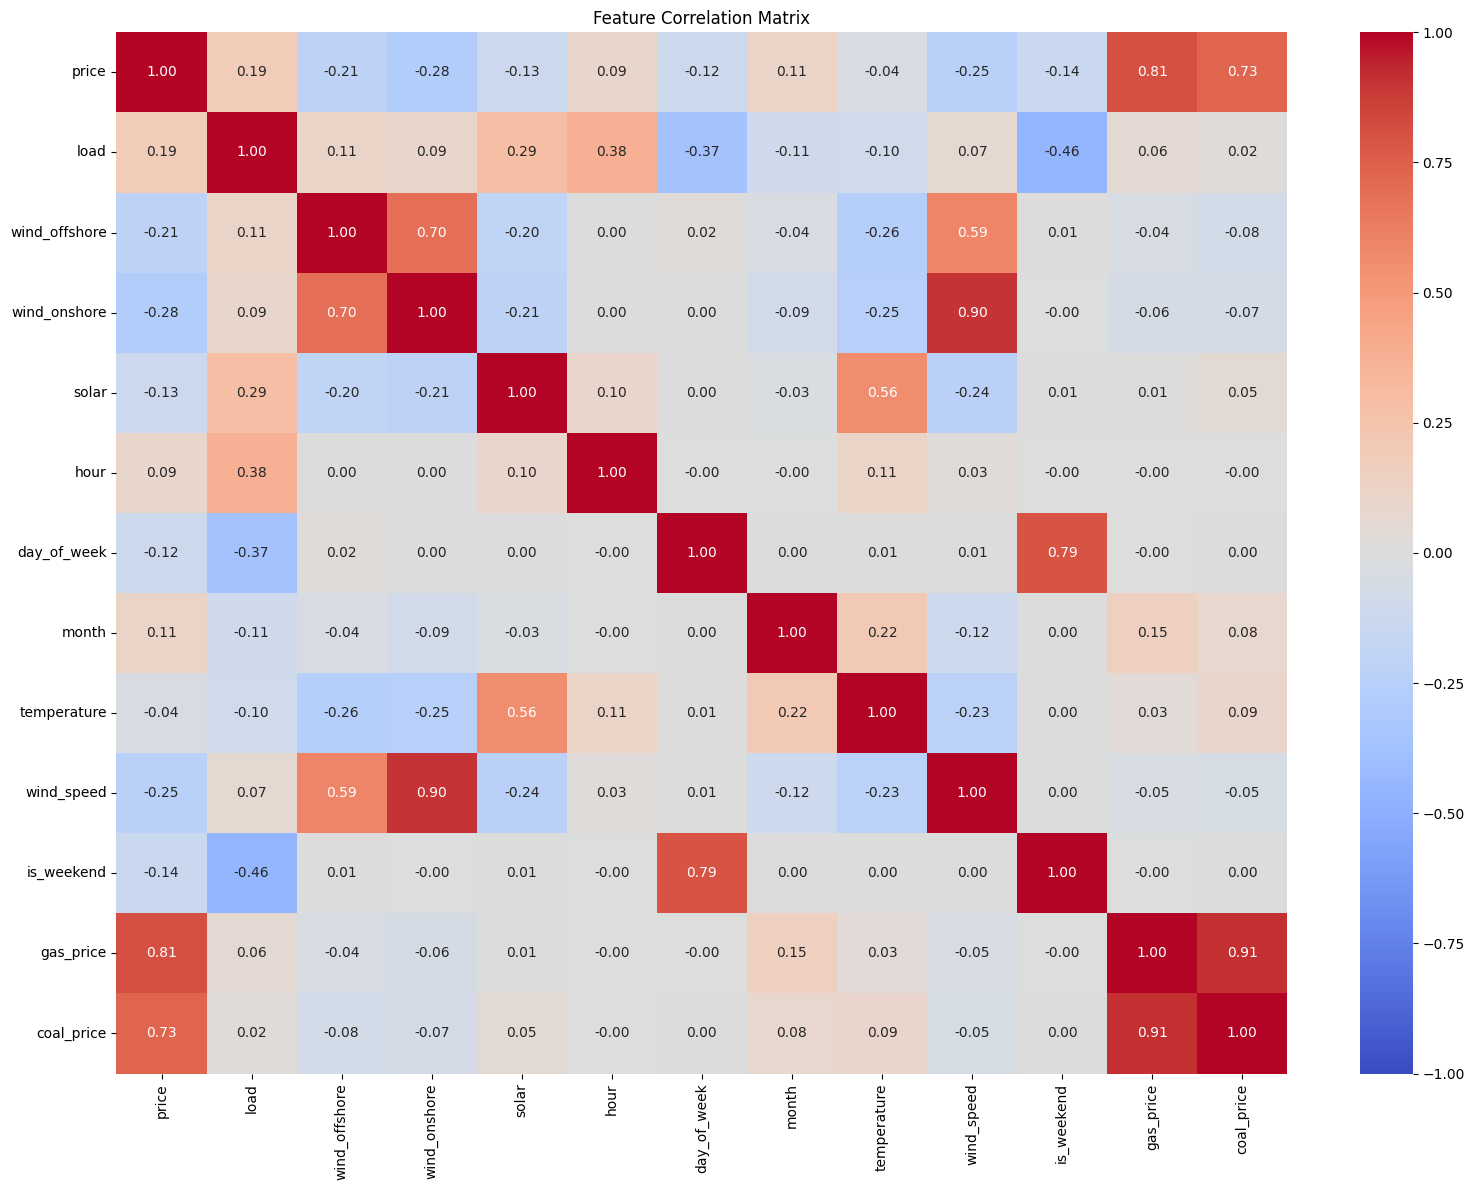

In [53]:
# Create a figure for the heatmap
plt.figure(figsize=(16, 12))

# Plot the correlation matrix as a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

# Add a title to the plot
plt.title("Feature Correlation Matrix")

# Adjust the layout to fit all elements
plt.tight_layout()

# Display the plot
plt.show()

### Drop selected features after the correlation analysis

In [54]:
# Create a new DataFrame without the wind_speed and is_weekend columns
df_finall = df_final.drop(columns=["wind_speed", "is_weekend"])

# Display the remaining column names
df_finall.columns

Index(['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar',
       'hour', 'day_of_week', 'month', 'temperature', 'gas_price',
       'coal_price'],
      dtype='object')

### Load the CO₂ price dataset

In [55]:
# Read the CO2 price data from a CSV file
icap = pd.read_csv("../data/icap-graph-price-data-2019-01-07-2025-12-05.csv")  # ili .xlsx

### Inspect the raw CO₂ price dataset

In [56]:
# Display the size of the CO2 price DataFrame as (rows, columns)
print(icap.shape)

# Display the first 10 rows of the CO2 price DataFrame
print(icap.head(10))

# Display the data types of the CO2 price DataFrame
print(icap.dtypes)

# Count missing values in each column
print(icap.isnull().sum())

(1550, 7)
   Unnamed: 0 European Union Emissions Trading System (from 2019, download)   
0        Date                              Exchange rate EUR/EUR             \
1  2019-01-07                                                  1              
2  2019-01-08                                                  1              
3  2019-01-10                                                  1              
4  2019-01-14                                                  1              
5  2019-01-15                                                  1              
6  2019-01-16                                                  1              
7  2019-01-17                                                  1              
8  2019-01-21                                                  1              
9  2019-01-22                                                  1              

              Unnamed: 2       Unnamed: 3      Unnamed: 4        Unnamed: 5     
0  Exchange rate EUR/USD  Market Curren

### Fix the column headers in the CO₂ price dataset

In [57]:
# Replace the current column names with the values from the first row
icap.columns = icap.iloc[0]

# Remove the first row because it is now used as the header
icap = icap.drop(0).reset_index(drop=True)

### Keep the timestamp and CO₂ price columns

In [58]:
# Select only the Date and Primary Market columns
co2 = icap[["Date", "Primary Market"]].copy()

# Rename the columns to timestamp and co2_price
co2.columns = ["timestamp", "co2_price"]

### Convert the CO₂ dataset columns to the correct data types

In [59]:
# Convert the timestamp column to datetime format
co2["timestamp"] = pd.to_datetime(co2["timestamp"])

# Convert the CO2 price column to numeric format
co2["co2_price"] = pd.to_numeric(co2["co2_price"], errors="coerce")

### Fill missing CO₂ prices with the previous available value

In [60]:
# Fill missing CO2 prices with the previous available value
co2["co2_price"] = co2["co2_price"].ffill()

### Inspect the prepared CO₂ price dataset

In [61]:
# Display the size of the CO2 price DataFrame as (rows, columns)
print(co2.shape)

# Display the first 5 rows of the CO2 price DataFrame
print(co2.head(5))

# Display the date range of the CO2 price DataFrame
print(f"Range: {co2['timestamp'].min()} to {co2['timestamp'].max()}")

# Count missing values in each column
print(f"Nulls: {co2.isnull().sum()}")

(1549, 2)
   timestamp  co2_price
0 2019-01-07      23.01
1 2019-01-08      22.40
2 2019-01-10      21.40
3 2019-01-14      21.95
4 2019-01-15      22.55
Range: 2019-01-07 00:00:00 to 2025-12-05 00:00:00
Nulls: timestamp    0
co2_price    0
dtype: int64


### Resample CO₂ prices to hourly frequency

In [62]:
# Resample the CO2 price data from daily to hourly frequency
co2_hourly = resample_to_hourly(co2)

# Convert the timestamp column to datetime format without timezone information
co2_hourly["timestamp"] = pd.to_datetime(co2_hourly["timestamp"]).dt.tz_localize(None)

### Merge the hourly CO₂ prices into the final dataset

In [63]:
# Merge the hourly CO2 price data into the final DataFrame using the timestamp column
df_final = df_final.merge(co2_hourly, on="timestamp", how="left")

### Fill missing CO₂ prices in the final dataset

In [64]:
# Fill missing CO2 prices with the previous and next available values
df_final["co2_price"] = df_final["co2_price"].ffill().bfill()

### Inspect the final dataset after adding CO₂ prices

In [65]:
# Display the total number of missing values in the final DataFrame
print(f"Nulls: {df_final.isnull().sum().sum()}")

# Display the size of the final DataFrame as (rows, columns)
print(f"Shape: {df_final.shape}")

# Display the first 2 rows of the final DataFrame
df_final.head(2)

Nulls: 0
Shape: (62945, 15)


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,co2_price
0,2019-01-01 00:00:00,28.32,43213.25,5069.00,18879.75,0.0,0,1,1,6.3750,27.820704,False,22.475,85.449997,23.01
1,2019-01-01 01:00:00,10.07,41275.75,5042.25,20626.50,0.0,1,1,1,6.3375,29.881138,False,22.475,85.449997,23.01
